In [2]:
import os
import joblib
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [3]:
model = joblib.load("../models/best_emotion_model.pkl")
scaler = joblib.load("../models/scaler.pkl")
label_encoder = joblib.load("../models/label_encoder.pkl")

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [4]:
feature_df = pd.read_csv("../outputs/features_dataset.csv")

feature_df.head()

,0,1,2,3,4,5,6,7,8,9,...,147,148,149,150,151,152,153,154,155,Emotion
0,-726.217224,68.541420,3.293398,12.205300,5.510278,13.667408,-2.983828,3.098029,-3.310813,-1.564384,...,4.124777e-08,2.838040e-08,2.313613e-08,1.160461e-08,5.817648e-09,5.361052e-09,0.050476,0.002120,7416.297748,Neutral
1,-719.128296,70.201569,1.168397,13.122541,7.836950,14.411290,-4.111360,4.468973,-3.539367,-3.658607,...,5.679201e-08,4.239203e-08,2.718321e-08,2.001875e-08,6.524588e-09,5.564329e-09,0.052904,0.002258,7135.571471,Neutral
2,-714.995728,69.689346,3.924564,11.924190,6.421723,11.011614,-2.878103,4.509558,-4.476109,-2.671549,...,2.857482e-07,3.092056e-07,3.254221e-07,1.852740e-07,2.746004e-08,5.536617e-09,0.046627,0.002707,7239.265648,Neutral
3,-710.975281,67.564880,5.782241,13.230726,6.190845,12.628252,-1.675169,5.657494,-4.950634,-3.477545,...,5.594725e-07,2.913224e-07,1.172284e-07,4.113968e-08,7.309259e-09,5.700877e-09,0.053835,0.002521,7008.958169,Neutral
4,-759.921753,75.783524,6.023605,14.557394,6.454187,14.631508,-3.004551,4.620970,-5.200016,-0.707430,...,3.130156e-08,1.891350e-08,1.092557e-08,6.905552e-09,5.926896e-09,5.486473e-09,0.045929,0.001579,6997.311810,Calm


In [5]:
X = feature_df.drop("Emotion", axis=1)

y = feature_df["Emotion"]

print(X.shape)
print(y.shape)

(1440, 156)
(1440,)


In [6]:
y_encoded = label_encoder.transform(y)

print(label_encoder.classes_)

['Angry' 'Calm' 'Disgust' 'Fearful' 'Happy' 'Neutral' 'Sad' 'Surprised']


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [8]:
X_test_scaled = scaler.transform(X_test)

In [9]:
y_pred = model.predict(X_test_scaled)

print("Prediction Completed!")

Prediction Completed!


In [10]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy : {accuracy:.4f}")

Test Accuracy : 0.5451


In [11]:
report = classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
)

print(report)

              precision    recall  f1-score   support

       Angry       0.73      0.63      0.68        38
        Calm       0.60      0.82      0.69        38
     Disgust       0.43      0.63      0.51        38
     Fearful       0.56      0.46      0.51        39
       Happy       0.50      0.46      0.48        39
     Neutral       0.38      0.26      0.31        19
         Sad       0.63      0.50      0.56        38
   Surprised       0.50      0.46      0.48        39

    accuracy                           0.55       288
   macro avg       0.54      0.53      0.53       288
weighted avg       0.55      0.55      0.54       288



In [12]:
with open("../reports/classification_report.txt", "w") as f:
    f.write(report)

print("Classification Report Saved!")

Classification Report Saved!


In [13]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[24  0  4  1  3  0  1  5]
 [ 0 31  2  0  0  3  1  1]
 [ 1  3 24  1  4  0  1  4]
 [ 3  0 10 18  3  0  3  2]
 [ 3  4  3  7 18  0  3  1]
 [ 0  6  3  0  2  5  1  2]
 [ 1  6  2  2  1  4 19  3]
 [ 1  2  8  3  5  1  1 18]]


<Figure size 1000x800 with 0 Axes>

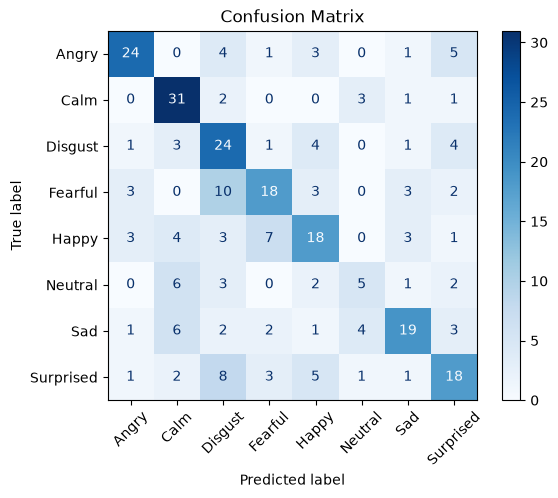

In [14]:
plt.figure(figsize=(10,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix")

plt.show()

<Figure size 1000x800 with 0 Axes>

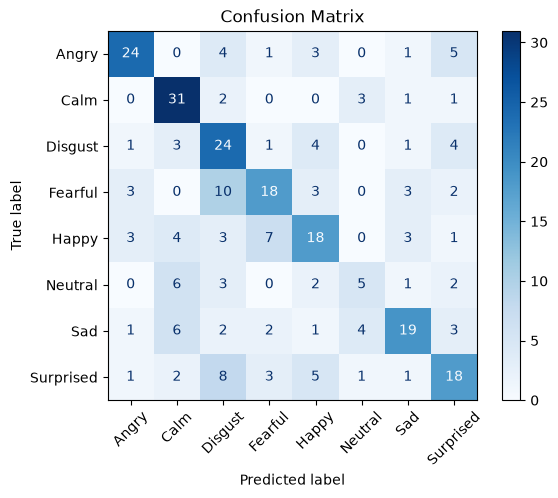

Confusion Matrix Saved!


In [15]:
plt.figure(figsize=(10,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix")

plt.savefig(
    "../reports/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion Matrix Saved!")

In [16]:
comparison = pd.DataFrame({
    "Actual": label_encoder.inverse_transform(y_test),
    "Predicted": label_encoder.inverse_transform(y_pred)
})

comparison.head(20)

,Actual,Predicted
0,Sad,Surprised
1,Calm,Calm
2,Happy,Calm
3,Angry,Angry
4,Neutral,Calm
5,Angry,Surprised
6,Angry,Surprised
7,Fearful,Sad
8,Disgust,Sad
9,Angry,Angry


In [17]:
comparison.to_csv(
    "../reports/prediction_results.csv",
    index=False
)

print("Prediction Results Saved!")

Prediction Results Saved!
